<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None
0      0
1      0
2      0
3      0
4      0
      ..
145    2
146    2
147    2
148    2
149    2
Name: species, Length: 150, dtype: int64
Accuracy Score:92.11%


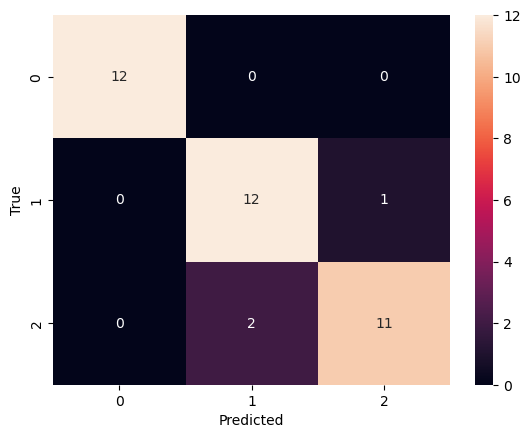

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,confusion_matrix
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
xg=XGBClassifier(
    n_estimators=100,
    learning_rate=0.4,
    max_depth=4,
    colsample_bytree=0.8
)
ohe=LabelEncoder()
df=pd.read_csv(r'IRIS.csv')
print(df.info())
x=df.drop(['species'],axis='columns')
df['species']=ohe.fit_transform(df['species'])
y=df['species']
print(y)
X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=0.25,shuffle=True,stratify=y,random_state=42)
xg.fit(X_train,y_train)
pred=xg.predict(X_test)
print(f"Accuracy Score:{accuracy_score(y_test,pred)*100:.2f}%")
cm=confusion_matrix(y_test,pred)
sns.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()